In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from single_cell_model import Environment, Cell

# For reproducibility
np.random.seed(42)

In [7]:
# Create a discrete concentration field (e.g., a 2D Gaussian bump)
grid_size = 50
x_linspace = np.linspace(-5, 5, grid_size)
y_linspace = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x_linspace, y_linspace)

# Concentration is high in the center, low on the edges
concentration_matrix = np.exp(-0.2 * (X**2 + Y**2)) 
env = Environment(concentration_matrix, dx=1.0)

# Define mu(c): Let's assume production mean scales linearly with concentration
def mu_func(c):
    return c 

# Simulation parameters
num_cells = 100
dt = 0.01
T = 50.0  # Total time
steps = int(T / dt)

# Initialize cells randomly in the center of the grid
cells = []
for _ in range(num_cells):
    x0, y0 = np.random.uniform(20, 30, size=2) # Start near the middle
    cells.append(Cell(
        x0=x0, y0=y0, 
        g0=0.0, q0=0.0, 
        beta=0.5,    # Degradation rate
        gamma=1.0,   # OU relaxation rate
        D_q=0.5,     # Noise in production rate
        D_x=2.0,     # Spatial diffusion (Brownian motion)
        mu_func=mu_func
    ))

In [8]:
print(f"Simulating {num_cells} cells for {steps} steps...")
for step in range(steps):
    for cell in cells:
        cell.step(dt, env)
print("Simulation complete.")

Simulating 100 cells for 5000 steps...
Simulation complete.


In [9]:
# Flatten the data to look at spatial correlations
data = []
for cell_id, cell in enumerate(cells):
    # Get the last 1000 steps (steady state) for spatial analysis
    x_hist = cell.history['x'][-1000:]
    y_hist = cell.history['y'][-1000:]
    g_hist = cell.history['g'][-1000:]
    
    for x, y, g in zip(x_hist, y_hist, g_hist):
        # Map continuous positions back to the discrete space
        i, j = env.get_discrete_pos(x, y)
        data.append({
            'cell_id': cell_id,
            'grid_x': i,
            'grid_y': j,
            'g': g,
            'c': env.c_field[i, j]
        })

df = pd.DataFrame(data)

# Calculate the mean gene expression 'g' for every discrete grid coordinate
spatial_corr = df.groupby(['grid_x', 'grid_y'])[['g', 'c']].mean().reset_index()

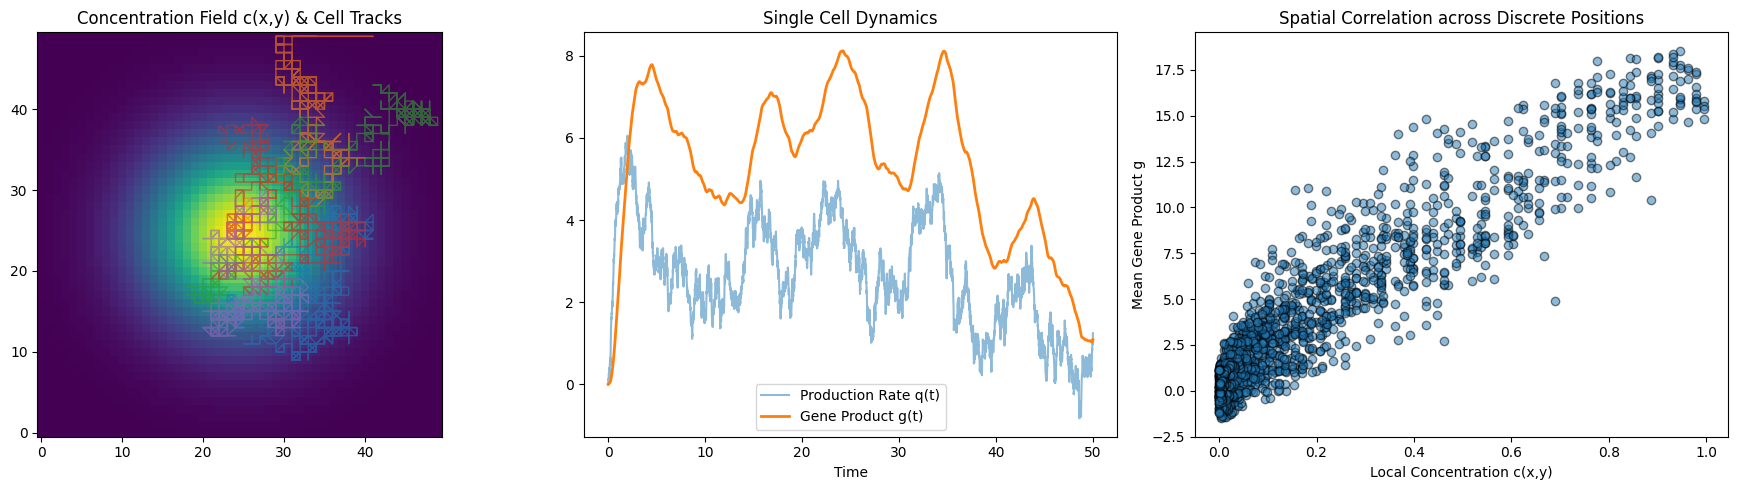

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. The Environment & Cell Trajectories
axes[0].imshow(env.c_field, cmap='viridis', origin='lower')
for cell in cells[:5]:  # Plot tracks for the first 5 cells
    x_discrete = [env.get_discrete_pos(x, y)[1] for x, y in zip(cell.history['x'], cell.history['y'])]
    y_discrete = [env.get_discrete_pos(x, y)[0] for x, y in zip(cell.history['x'], cell.history['y'])]
    axes[0].plot(x_discrete, y_discrete, alpha=0.6, linewidth=1)
axes[0].set_title('Concentration Field c(x,y) & Cell Tracks')

# 2. Gene Product g and Rate q over time for one cell
time = np.arange(steps + 1) * dt
sample_cell = cells[0]
axes[1].plot(time, sample_cell.history['q'], alpha=0.5, label='Production Rate q(t)')
axes[1].plot(time, sample_cell.history['g'], linewidth=2, label='Gene Product g(t)')
axes[1].set_xlabel('Time')
axes[1].set_title('Single Cell Dynamics')
axes[1].legend()

# 3. Spatial Correlation: Concentration vs Mean Gene Expression
axes[2].scatter(spatial_corr['c'], spatial_corr['g'], alpha=0.5, edgecolor='k')
axes[2].set_xlabel('Local Concentration c(x,y)')
axes[2].set_ylabel('Mean Gene Product g')
axes[2].set_title('Spatial Correlation across Discrete Positions')

plt.tight_layout()
plt.show()

Calculating pairwise distances and covariances...


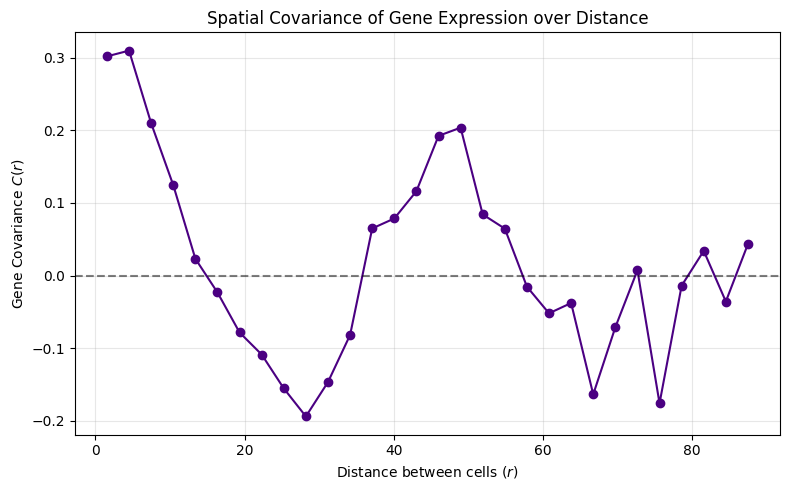

In [10]:
from scipy.spatial.distance import pdist
import warnings

# Suppress runtime warnings for empty bins during calculation
warnings.filterwarnings('ignore', category=RuntimeWarning)

# We will average over the last 200 time steps to smooth out stochastic noise
tail_steps = 200
all_distances = []
all_covariances = []

print("Calculating pairwise distances and covariances...")
for t in range(steps - tail_steps, steps):
    # 1. Extract snapshot of positions and gene products at time t
    x_t = np.array([cell.history['x'][t] for cell in cells])
    y_t = np.array([cell.history['y'][t] for cell in cells])
    g_t = np.array([cell.history['g'][t] for cell in cells])
    
    # 2. Calculate the fluctuations from the mean at this time step
    g_mean = np.mean(g_t)
    g_fluc = g_t - g_mean
    
    # 3. Calculate pairwise distances (condensed 1D array)
    pos_t = np.column_stack((x_t, y_t))
    dist_t = pdist(pos_t)
    
    # 4. Calculate pairwise covariance 
    # np.outer gives the matrix of all (g_i - mean)(g_j - mean)
    # We use triu_indices to extract the upper triangle, matching the pdist output
    n = len(cells)
    i_idx, j_idx = np.triu_indices(n, k=1)
    cov_t = np.outer(g_fluc, g_fluc)[i_idx, j_idx]
    
    # Store for binning
    all_distances.extend(dist_t)
    all_covariances.extend(cov_t)

all_distances = np.array(all_distances)
all_covariances = np.array(all_covariances)

# 5. Bin the covariances by distance
num_bins = 30
# Create distance bins from the minimum to the maximum observed distance
bins = np.linspace(all_distances.min(), all_distances.max(), num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_indices = np.digitize(all_distances, bins)

binned_cov = []
for b in range(1, len(bins)):
    mask = (bin_indices == b)
    if np.sum(mask) > 0:
        binned_cov.append(np.mean(all_covariances[mask]))
    else:
        binned_cov.append(np.nan) # Handle empty bins

# 6. Plotting the Spatial Covariance
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, binned_cov, marker='o', linestyle='-', color='indigo')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Distance between cells ($r$)')
plt.ylabel('Gene Covariance $C(r)$')
plt.title('Spatial Covariance of Gene Expression over Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()